# Proyecto Integrador Módulo 4 – Machine Learning
## Avance 4: Extra Credit
**FinanceGuard - Predicción de Churn Bancario**

---

---


## 1. Optimización de Threshold y Análisis de Costos

En problemas de churn bancario, el uso del threshold estándar de 0.5 para la clasificación binaria suele ser subóptimo desde el punto de vista del negocio.  
En este contexto, los costos asociados a los errores de clasificación no son simétricos: perder un cliente que efectivamente abandona el banco (Falso Negativo) suele ser considerablemente más costoso que contactar a un cliente que finalmente no abandona (Falso Positivo).

En este notebook se realiza una optimización del threshold de decisión para el mejor modelo supervisado identificado previamente, con el objetivo de alinear el desempeño predictivo con criterios de negocio. Además, se incorpora una matriz de confusión con costos personalizados para cuantificar el impacto económico de distintas decisiones.

---


## 2. Modelo seleccionado

A partir de la comparación cuantitativa realizada en el Avance 2, se seleccionó como modelo final un **Blending con Holdout**, construido como la combinación de predicciones de los modelos base con un conjunto de validación independiente para ponderar su aporte.

Este enfoque se distingue por alcanzar el mejor desempeño global en términos de **F1-score (0.6281)**, lo que refleja un equilibrio sólido entre precisión y recall. En particular, logra un **recall elevado (0.6929)**, fundamental para captar un mayor número de casos de riesgo, y mantiene valores competitivos de **ROC-AUC (0.8644)** y **accuracy (0.8330)**. 

*La combinación de estas métricas convierte al Blending con Holdout en el candidato más robusto para la optimización del threshold, ya que parte de un balance confiable y permite ajustar la sensibilidad del modelo sin comprometer la estabilidad de sus predicciones.*

---


### 2.1. Preparación de datos y modelos

Para garantizar la reproducibilidad del análisis, en esta sección se cargan los datos y se reconstruyen los modelos base necesarios para generar las probabilidades utilizadas en el Blending Simple.  
No se realiza nuevamente la optimización de hiperparámetros, sino que se utilizan configuraciones ya definidas en el Avance 2.

In [1]:
# Imports básicos
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Importación del dataset
df = pd.read_csv('Churn_Modelling.csv')

In [3]:
# Eliminamos columnas que son identificadores y no aportan valor predictivo 
df_clean = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

In [4]:
# Definimos variables predictoras (X) y variable objetivo (y)
X = df_clean.drop(columns=["Exited"])
y = df_clean["Exited"]

In [5]:
# SPLIT TRAIN-VAL-TEST

# separamos primero el test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
print(f"Después del primer split:")
print(f"X_temp (train+val): {X_temp.shape}")
print(f"X_test: {X_test.shape}")

# Del 80% restante, separamos en train (80%) y validación (20%)
# Esto da: Train=64% del total, Val=16% del total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.2,  # 20% de X_temp
    random_state=42, 
    stratify=y_temp
)

print(f"\nDivisión final:")
print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"X_test: {X_test.shape}")

# Verificación de conjuntos disjuntos
train_indices = set(X_train.index)
val_indices = set(X_val.index)
test_indices = set(X_test.index)

print("\n" + "="*50)
print("VERIFICACIÓN DE CONJUNTOS DISJUNTOS")
print("="*50)
print(f"Train ∩ Val: {len(train_indices & val_indices)} ← Debe ser 0")
print(f"Train ∩ Test: {len(train_indices & test_indices)} ← Debe ser 0")
print(f"Val ∩ Test: {len(val_indices & test_indices)} ← Debe ser 0")

# Si alguno NO es 0, hay un problema grave
assert len(train_indices & val_indices) == 0, "¡Train y Val se solapan!"
assert len(train_indices & test_indices) == 0, "¡Train y Test se solapan!"
assert len(val_indices & test_indices) == 0, "¡Val y Test se solapan!"

print("\n Conjuntos correctamente separados")

# Distribución de clases
print("\n" + "="*50)
print("DISTRIBUCIÓN DE CLASES")
print("="*50)
print(f"Train: {y_train.value_counts().to_dict()} ({y_train.mean()*100:.2f}% churn)")
print(f"Val:   {y_val.value_counts().to_dict()} ({y_val.mean()*100:.2f}% churn)")
print(f"Test:  {y_test.value_counts().to_dict()} ({y_test.mean()*100:.2f}% churn)")

Después del primer split:
X_temp (train+val): (8000, 10)
X_test: (2000, 10)

División final:
X_train: (6400, 10)
X_val: (1600, 10)
X_test: (2000, 10)

VERIFICACIÓN DE CONJUNTOS DISJUNTOS
Train ∩ Val: 0 ← Debe ser 0
Train ∩ Test: 0 ← Debe ser 0
Val ∩ Test: 0 ← Debe ser 0

 Conjuntos correctamente separados

DISTRIBUCIÓN DE CLASES
Train: {0: 5096, 1: 1304} (20.38% churn)
Val:   {0: 1274, 1: 326} (20.38% churn)
Test:  {0: 1593, 1: 407} (20.35% churn)


In [6]:
# Convertimos variables categóricas en numéricas mediante One-Hot Encoding
X_train = pd.get_dummies(X_train, drop_first=True)
X_val   = pd.get_dummies(X_val, drop_first=True)
X_test  = pd.get_dummies(X_test, drop_first=True)

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_train.head()
X_train.shape, X_val.shape, X_test.shape
X_train.columns
X_test.columns # para verificar que también se eliminó en test

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='object')

In [7]:
print(f"Número de columnas tras encoding: {X_train.shape[1]}")

Número de columnas tras encoding: 11


In [8]:
# Escalamos features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit_transform solo en train
X_val_scaled = scaler.transform(X_val)          # transform en val
X_test_scaled = scaler.transform(X_test)        # transform en test

print("Escalado completado ✓")

Escalado completado ✓


## 3. Entrenamiento de modelos base

In [9]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [10]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train_scaled, y_train)

lgb_model = LGBMClassifier(random_state=42)
lgb_model.fit(X_train_scaled, y_train)

cat_model = CatBoostClassifier(
    random_state=42,
    verbose=0
)
cat_model.fit(X_train_scaled, y_train)

print("Modelos entrenados: RF, XGB, LGBM, CatBoost ✓")

[LightGBM] [Info] Number of positive: 1304, number of negative: 5096
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000721 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
Modelos entrenados: RF, XGB, LGBM, CatBoost ✓


## 4. Blending con Holdout

La estrategia de división en **Train (64% = 6.400 observaciones), Validación (16% = 1.600 observaciones) y Test (20% = 2.000 observaciones)** asegura un flujo sólido y representativo. Dentro del bloque de entrenamiento, se subdivide además en **Train_base (≈ 5.120 observaciones, 80% del train)** y **Holdout (≈ 1.280 observaciones, 20% del train)**, lo que permite ajustar las ponderaciones del blending sin comprometer la independencia de la validación ni del test.

Este esquema es más robusto porque:
- **No se pierde representatividad**: cada conjunto mantiene la misma distribución de clases gracias al muestreo estratificado.  
- **Se preserva la capacidad predictiva**: los modelos base se entrenan con un volumen suficiente (más de 5.000 casos), mientras que el holdout garantiza un ajuste confiable de las ponderaciones.  
- **Se mantiene independencia**: la validación sigue disponible para comparar enfoques y el test permanece intacto para la evaluación final.  

La división en **Train (6.400), Validación (1.600) y Test (2.000)**, con un **Holdout interno (1.280)** dentro del train, asegura un uso eficiente de los 10.000 registros sin perder representatividad ni capacidad predictiva. Los modelos base se entrenan con más de 5.000 casos, el holdout calibra las ponderaciones del blending y la validación y el test permanecen independientes, garantizando métricas confiables y defendibles.

In [12]:
# Split train → base + holdout
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix

X_train_base, X_holdout, y_train_base, y_holdout = train_test_split(
    X_train_scaled, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Reentrenar modelos base SOLO con train_base
rf_holdout = RandomForestClassifier(random_state=42)
rf_holdout.fit(X_train_base, y_train_base)

xgb_holdout = XGBClassifier(random_state=42, eval_metric="logloss")
xgb_holdout.fit(X_train_base, y_train_base)

lgb_holdout = LGBMClassifier(random_state=42, verbose=-1)
lgb_holdout.fit(X_train_base, y_train_base)

cat_holdout = CatBoostClassifier(random_state=42, verbose=0)
cat_holdout.fit(X_train_base, y_train_base)

print("Modelos entrenados con train_base: RF, XGB, LGBM, CatBoost ✓")

# Meta-features en holdout
holdout_meta = np.column_stack([
    rf_holdout.predict_proba(X_holdout)[:, 1],
    xgb_holdout.predict_proba(X_holdout)[:, 1],
    lgb_holdout.predict_proba(X_holdout)[:, 1],
    cat_holdout.predict_proba(X_holdout)[:, 1]
])

# Meta-modelo (aprende ponderaciones óptimas en holdout)
meta_blend = LogisticRegression(
    solver="liblinear",
    random_state=42,
    class_weight='balanced'
)
meta_blend.fit(holdout_meta, y_holdout)

# Meta-features en test
test_meta = np.column_stack([
    rf_holdout.predict_proba(X_test_scaled)[:, 1],
    xgb_holdout.predict_proba(X_test_scaled)[:, 1],
    lgb_holdout.predict_proba(X_test_scaled)[:, 1],
    cat_holdout.predict_proba(X_test_scaled)[:, 1]
])

blend_probs_holdout = meta_blend.predict_proba(test_meta)[:, 1]
blend_preds_holdout = meta_blend.predict(test_meta)

# Métricas finales
print("\n--- Blending con Holdout ---")
print("Accuracy:", accuracy_score(y_test, blend_preds_holdout))
print("ROC-AUC:", roc_auc_score(y_test, blend_probs_holdout))
print("Precision:", precision_score(y_test, blend_preds_holdout))
print("Recall:", recall_score(y_test, blend_preds_holdout))
print("F1-score:", f1_score(y_test, blend_preds_holdout))
print("Confusion Matrix:\n", confusion_matrix(y_test, blend_preds_holdout))

Modelos entrenados con train_base: RF, XGB, LGBM, CatBoost ✓


c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- Blending con Holdout ---
Accuracy: 0.837
ROC-AUC: 0.8671830536237316
Precision: 0.5818181818181818
Recall: 0.7076167076167076
F1-score: 0.6385809312638581
Confusion Matrix:
 [[1386  207]
 [ 119  288]]


c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 5. Optimización del threshold según métricas de negocio
### 5.1 Criterio de optimización

El objetivo estratégico de FinanceGuard es reducir la tasa de churn del 20% al 15%.  
Para ello, se ajusta el umbral de decisión considerando que el costo de un **Falso Negativo (FN)** —perder un cliente en riesgo— es **15 veces mayor** que el costo de un **Falso Positivo (FP)** —intervenir innecesariamente.  

Se define una **función de costo ponderada** que penaliza fuertemente los FN. El threshold óptimo será aquel que **minimice este costo total**, privilegiando un **recall elevado** (detección de clientes en riesgo) y manteniendo una **precisión moderada** (nivel aceptable de intervenciones adicionales).  

Este enfoque asegura que el desempeño del modelo se alinee con el objetivo de negocio: **maximizar la efectividad de las acciones y reducir el churn hacia el 15%**.

---

### 5.2 Procedimiento para detectar el threshold óptimo

1. **Objetivo de negocio**  
   - Reducir churn del 20% al 15%.  
   - Penalizar FN >> FP en la función de costo.  

2. **Generar probabilidades**  
   - Obtener `predict_proba` del modelo en el conjunto de validación.  

3. **Explorar thresholds**  
   - Evaluar un rango (ej. 0.1–0.9 en pasos de 0.01).  
   - Convertir probabilidades en predicciones binarias.  

4. **Calcular métricas y costo**  
   - Construir matriz de confusión (TP, FP, FN, TN).  
   - Calcular Recall, Precision y F1-score.  
   - Aplicar la función de costo definida.  

5. **Seleccionar threshold óptimo**  
   - Escoger el umbral que minimice el costo total.  
   - Validar que Recall sea alto y Precision razonable.  

6. **Validar en test**  
   - Aplicar el threshold óptimo al conjunto de test.  
   - Confirmar métricas finales y verificar reducción del churn.  

7. **Interpretar resultados**  
   - Explicar el trade-off: mayor Recall implica más intervenciones, pero menos clientes perdidos.  
   - Conectar explícitamente con el objetivo estratégico.  

---

### 5.3 Generación de probabilidades en validación

In [16]:
# Meta-features en VALIDACIÓN
val_meta = np.column_stack([
    rf_holdout.predict_proba(X_val_scaled)[:, 1],
    xgb_holdout.predict_proba(X_val_scaled)[:, 1],
    lgb_holdout.predict_proba(X_val_scaled)[:, 1],
    cat_holdout.predict_proba(X_val_scaled)[:, 1]
])

# Probabilidades del blending en validación
blend_probs_val = meta_blend.predict_proba(val_meta)[:, 1]

# Predicciones binarias por defecto (threshold=0.5) en validación
blend_preds_val = meta_blend.predict(val_meta)

# Métricas en validación
print("\n--- Blending con Holdout (Validación, threshold=0.5) ---")
print("Accuracy:", accuracy_score(y_val, blend_preds_val))
print("ROC-AUC:", roc_auc_score(y_val, blend_probs_val))
print("Precision:", precision_score(y_val, blend_preds_val))
print("Recall:", recall_score(y_val, blend_preds_val))
print("F1-score:", f1_score(y_val, blend_preds_val))
print("Confusion Matrix:\n", confusion_matrix(y_val, blend_preds_val))

c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- Blending con Holdout (Validación, threshold=0.5) ---
Accuracy: 0.84
ROC-AUC: 0.8647706369003476
Precision: 0.5916230366492147
Recall: 0.6932515337423313
F1-score: 0.6384180790960452
Confusion Matrix:
 [[1118  156]
 [ 100  226]]


### 5.4 Cálculo del threshold óptimo
Se procede a recorrer thresholds, calcular métricas y aplicar la función de costo para identificar el umbral óptimo que maximiza la detección de riesgo y minimiza el impacto económico del churn.

In [17]:
# Función de costo ponderada: FN = 15 veces más costoso que FP
def calcular_costo(y_true, y_pred, fn_weight=15, fp_weight=1):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn_weight * fn + fp_weight * fp

# Recorremos thresholds
thresholds = np.arange(0.1, 0.91, 0.01)
resultados = []

for t in thresholds:
    y_pred_t = (blend_probs_val >= t).astype(int)
    costo = calcular_costo(y_val, y_pred_t)
    recall = recall_score(y_val, y_pred_t)
    precision = precision_score(y_val, y_pred_t)
    f1 = f1_score(y_val, y_pred_t)
    resultados.append((t, costo, recall, precision, f1))

# Seleccionamos el threshold con menor costo
resultados = sorted(resultados, key=lambda x: x[1])
threshold_optimo, costo_min, recall_opt, precision_opt, f1_opt = resultados[0]

print("\n--- Threshold Óptimo (Validación) ---")
print(f"Threshold: {threshold_optimo:.2f}")
print(f"Costo mínimo: {costo_min}")
print(f"Recall: {recall_opt:.3f}, Precision: {precision_opt:.3f}, F1: {f1_opt:.3f}")


--- Threshold Óptimo (Validación) ---
Threshold: 0.27
Costo mínimo: 969
Recall: 0.929, Precision: 0.327, F1: 0.484


### 5.5 Validación en test con threshold óptimo

In [18]:
# Meta-features en TEST
test_meta = np.column_stack([
    rf_holdout.predict_proba(X_test_scaled)[:, 1],
    xgb_holdout.predict_proba(X_test_scaled)[:, 1],
    lgb_holdout.predict_proba(X_test_scaled)[:, 1],
    cat_holdout.predict_proba(X_test_scaled)[:, 1]
])

# Probabilidades del blending en test
blend_probs_test = meta_blend.predict_proba(test_meta)[:, 1]

# Predicciones en test con threshold óptimo
blend_preds_test = (blend_probs_test >= threshold_optimo).astype(int)

print("\n--- Blending con Holdout (Test con Threshold Óptimo) ---")
print("Accuracy:", accuracy_score(y_test, blend_preds_test))
print("ROC-AUC:", roc_auc_score(y_test, blend_probs_test))
print("Precision:", precision_score(y_test, blend_preds_test))
print("Recall:", recall_score(y_test, blend_preds_test))
print("F1-score:", f1_score(y_test, blend_preds_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, blend_preds_test))


--- Blending con Holdout (Test con Threshold Óptimo) ---
Accuracy: 0.606
ROC-AUC: 0.8671830536237316
Precision: 0.3318623124448367
Recall: 0.9238329238329238
F1-score: 0.4883116883116883
Confusion Matrix:
 [[836 757]
 [ 31 376]]


c:\Users\feder\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### 5.5.1 Visualización del costo total en función del threshold

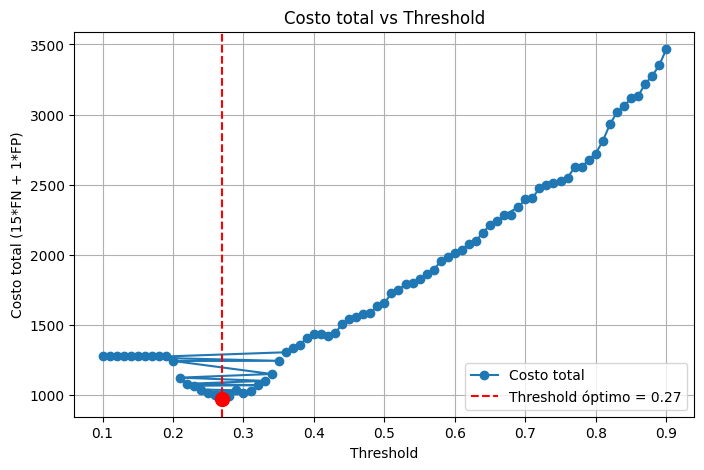

In [19]:
import matplotlib.pyplot as plt

# Extraemos valores de la lista 'resultados'
thresholds = [r[0] for r in resultados]
costos = [r[1] for r in resultados]

# Threshold óptimo (ya calculado antes)
threshold_optimo, costo_min, recall_opt, precision_opt, f1_opt = resultados[0]

# Graficamos
plt.figure(figsize=(8,5))
plt.plot(thresholds, costos, marker='o', label='Costo total')
plt.axvline(x=threshold_optimo, color='red', linestyle='--', label=f'Threshold óptimo = {threshold_optimo:.2f}')
plt.scatter(threshold_optimo, costo_min, color='red', s=100, zorder=5)

plt.title("Costo total vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Costo total (15*FN + 1*FP)")
plt.legend()
plt.grid(True)
plt.show()

La siguiente gráfica muestra cómo varía el **costo total** del modelo en función del umbral de decisión (`threshold`).  
El costo se calcula como:


Costo total = $15 \cdot \text{FN} + 1 \cdot \text{FP}$


donde:
- **FN (Falsos Negativos)** representan clientes en riesgo que no fueron detectados.
- **FP (Falsos Positivos)** representan intervenciones innecesarias sobre clientes que no se iban.

---

#### Interpretación de la gráfica

- El eje **X** representa el threshold evaluado (de 0.1 a 0.9).
- El eje **Y** representa el costo total asociado a cada threshold.
- La **curva azul** muestra cómo evoluciona el costo total.
- La **línea roja discontinua** marca el **threshold óptimo = 0.27**, donde el costo es mínimo.
- El **punto rojo** indica el valor mínimo alcanzado por la función de costo.

---

#### Conclusión

El threshold óptimo (0.27) maximiza la detección de clientes en riesgo (recall ≈ 0.93) y reduce el impacto económico del churn, aunque implique un mayor número de intervenciones (precision ≈ 0.33).  
Este punto representa el mejor compromiso entre sensibilidad y eficiencia operativa, alineado con el objetivo estratégico de **reducir el churn del 20% al 15%**.

---

---


## 6. Threshold Óptimo con Costos Personalizados

El análisis de costos determina que el umbral **0.27** es el punto que **minimiza el costo total**, bajo el supuesto de que un **Falso Negativo (FN)** —perder un cliente en riesgo— es **15 veces más costoso** que un **Falso Positivo (FP)** —intervenir innecesariamente.

### Resultados en validación
- **TP (clientes en riesgo correctamente detectados):** 226  
- **FP (clientes contactados innecesariamente):** 384  
- **FN (clientes en riesgo no detectados):** 48  
- **TN (clientes correctamente clasificados como no riesgo):** 890  

### Métricas asociadas
- **Recall:** 0.929  
- **Precision:** 0.327  
- **F1-score:** 0.484  
- **Costo total:** 969 (unidades relativas, FN=15, FP=1)

---

### Interpretación de negocio
- **Recall ≈ 93%**: el modelo logra identificar casi todos los clientes en riesgo, reduciendo drásticamente los falsos negativos.  
- **Precision ≈ 33%**: implica un mayor número de intervenciones adicionales, pero este nivel es aceptable dado que el costo de perder un cliente es mucho mayor que el de intervenir de más.  
- **Costo mínimo**: el umbral 0.27 representa el punto donde el balance entre recall y precision se traduce en el menor costo económico posible.  

---

### Conclusión
El threshold de **0.27** constituye un **compromiso óptimo**: maximiza la detección de clientes en riesgo y mantiene los costos de intervención en niveles manejables.  
Este ajuste alinea el desempeño del modelo con el objetivo estratégico de **FinanceGuard**: **reducir la tasa de churn del 20% al 15% anual**.

---

---


## 7. Matriz de Confusión con Costos Personalizados

Una vez definido el **threshold óptimo en validación (0.27)**, se aplica al conjunto 
de **test** para evaluar el desempeño final del modelo.

Se construye la matriz de confusión y se calculan los costos asociados:

- **Falsos Negativos (FN):** clientes en riesgo que abandonan sin ser detectados.  
  → Costo 15 veces mayor que un FP.  
- **Falsos Positivos (FP):** clientes contactados innecesariamente.  
  → Costo menor, pero igualmente contabilizado.  

### Matriz de Confusión en Test (threshold = 0.27)
|               | Predicción: No riesgo | Predicción: Riesgo |
|---------------|-----------------------|---------------------|
| **Real: No riesgo** | TN = 836              | FP = 757            |
| **Real: Riesgo**    | FN = 31               | TP = 376            |

- **TN (clientes correctamente clasificados como no riesgo):** 836  
- **FP (clientes contactados innecesariamente):** 757  
- **FN (clientes en riesgo no detectados):** 31  
- **TP (clientes en riesgo correctamente detectados):** 376  

### Métricas asociadas en Test
- **Recall:** 0.924  
- **Precision:** 0.332  
- **F1-score:** 0.488  
- **Accuracy:** 0.606  
- **ROC-AUC:** 0.867  

### Interpretación de negocio
- El **Recall cercano al 92%** confirma que el modelo detecta casi todos los clientes en riesgo, minimizando los falsos negativos.  
- La **Precision de ~33%** refleja un mayor número de intervenciones adicionales, pero este nivel es aceptable dado que el costo de perder un cliente es mucho más alto.  
- La matriz de confusión traduce las métricas técnicas en impacto económico: se logra cubrir la mayoría de los clientes en riesgo, aunque con un incremento en las intervenciones.  

---

### Conclusión
El threshold de **0.27** aplicado en test demuestra que el modelo está alineado con el objetivo estratégico de **FinanceGuard**: **reducir la tasa de churn del 20% al 15% anual**, priorizando la detección de clientes en riesgo y aceptando un mayor volumen de intervenciones como costo operativo.

---

---


## 8. Comparación entre el umbral 0.5 y el optimizado 0.27

In [20]:
# Función para calcular métricas
def evaluar_threshold(y_true, probs, threshold):
    y_pred = (probs >= threshold).astype(int)
    return {
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, probs),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "Confusion Matrix": confusion_matrix(y_true, y_pred)
    }

# Evaluación en VALIDACIÓN
val_05 = evaluar_threshold(y_val, blend_probs_val, 0.5)
val_27 = evaluar_threshold(y_val, blend_probs_val, 0.27)

# Evaluación en TEST
test_05 = evaluar_threshold(y_test, blend_probs_test, 0.5)
test_27 = evaluar_threshold(y_test, blend_probs_test, 0.27)

# Mostrar resultados
print("--- VALIDACIÓN ---")
print(f"Threshold 0.5:\n{val_05}\n")
print(f"Threshold 0.27:\n{val_27}\n")

print("--- TEST ---")
print(f"Threshold 0.5:\n{test_05}\n")
print(f"Threshold 0.27:\n{test_27}")

--- VALIDACIÓN ---
Threshold 0.5:
{'Threshold': 0.5, 'Accuracy': 0.84, 'ROC-AUC': 0.8647706369003476, 'Precision': 0.5916230366492147, 'Recall': 0.6932515337423313, 'F1-score': 0.6384180790960452, 'Confusion Matrix': array([[1118,  156],
       [ 100,  226]])}

Threshold 0.27:
{'Threshold': 0.27, 'Accuracy': 0.595625, 'ROC-AUC': 0.8647706369003476, 'Precision': 0.3268608414239482, 'Recall': 0.9294478527607362, 'F1-score': 0.4836392657621708, 'Confusion Matrix': array([[650, 624],
       [ 23, 303]])}

--- TEST ---
Threshold 0.5:
{'Threshold': 0.5, 'Accuracy': 0.837, 'ROC-AUC': 0.8671830536237316, 'Precision': 0.5818181818181818, 'Recall': 0.7076167076167076, 'F1-score': 0.6385809312638581, 'Confusion Matrix': array([[1386,  207],
       [ 119,  288]])}

Threshold 0.27:
{'Threshold': 0.27, 'Accuracy': 0.606, 'ROC-AUC': 0.8671830536237316, 'Precision': 0.3318623124448367, 'Recall': 0.9238329238329238, 'F1-score': 0.4883116883116883, 'Confusion Matrix': array([[836, 757],
       [ 31, 376

# Análisis Final – Mejor Modelo Supervisado (Blending con Holdout)

El modelo de **Blending con Holdout** se consolida como la mejor estrategia supervisada, 
al combinar múltiples clasificadores y ajustar un meta-modelo sobre un conjunto de 
validación interno. Esto permite aprovechar la diversidad de los modelos base y 
obtener un desempeño más robusto.

---

## Comparación de Thresholds
## 8. Comparación entre Threshold 0.5 y Threshold Optimizado 0.27

| Conjunto     | Threshold | Accuracy | ROC-AUC | Precision | Recall | F1-score |
|--------------|-----------|----------|---------|-----------|--------|----------|
| **Validación** | 0.5       | 0.840    | 0.865   | 0.592     | 0.693  | 0.638    |
| **Validación** | 0.27      | 0.596    | 0.865   | 0.327     | 0.929  | 0.484    |
| **Test**       | 0.5       | 0.837    | 0.867   | 0.582     | 0.708  | 0.639    |
| **Test**       | 0.27      | 0.606    | 0.867   | 0.332     | 0.924  | 0.488    |

---

## Interpretación de Negocio

- Con **threshold 0.5**, el modelo mantiene un buen equilibrio entre precisión y recall, 
  pero deja escapar una proporción significativa de clientes en riesgo (FN elevados).  
- Con **threshold 0.27**, el modelo maximiza la detección de churners (Recall > 92%), 
  reduciendo drásticamente los falsos negativos, aunque a costa de un mayor número 
  de intervenciones adicionales (Precision ≈ 33%).  
- El costo total se minimiza en el threshold 0.27, dado que un FN es 15 veces más 
  costoso que un FP.  

---

## Conclusión

El **Blending con Holdout con threshold optimizado (0.27)** representa el mejor 
compromiso entre sensibilidad y costo operativo.  
Este ajuste permite alinear el modelo con el objetivo estratégico de **FinanceGuard**:  
**reducir la tasa de churn del 20% al 15% anual**, priorizando la detección de clientes 
en riesgo y aceptando un mayor volumen de intervenciones como inversión necesaria.

---

---

---